In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv('train_titanic.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
data.Age.mean()

29.69911764705882

#### First Technique is that mean / median / mode 
* when should we use this: whenever we have a dataset of Missing completely at random(MCAR).

In [6]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age', 'Fare','Survived'])

In [7]:
data.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [8]:
def medain(data, variable):
    data[variable] = data[variable].fillna((data[variable].median()))

In [9]:
medain(data, 'Age')

In [10]:
data.Age = data.Age.astype(int)

In [11]:
data.head()

,Survived,Age,Fare
0,0,22,7.2500
1,1,38,71.2833
2,1,26,7.9250
3,1,35,53.1000
4,0,35,8.0500


In [12]:
# we can create multiple for loop for mean, median and mode and we can run through the for loop.

#### 2. Random Sample Imputation
* 	Its working on taking the random observation from the dataset and replace on the nan values.
*   We use this when our data is completly at random(MCAR)


In [13]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age', 'Fare','Survived'])

In [14]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [15]:
data.Age.sample()

339    45.0
Name: Age, dtype: float64

In [16]:
def medain(data, variable):
    data[variable+'_median'] = data[variable].fillna((data[variable].median()))
    data[variable + 'Random Sample'] = data[variable]
    random_sample = data[variable].dropna().sample(data[variable].isnull().sum(), random_state = 0)
    #The last sentence will give the random value for null datas
    random_sample.index = data[data[variable].isnull()].index
    data.loc[data[variable].isnull(), variable+'Random Sample'] = random_sample
    

In [17]:
medain(data, 'Age')

In [18]:
data.head()

,Survived,Age,Fare,Age_median,AgeRandom Sample
0,0,22.0,7.2500,22.0,22.0
1,1,38.0,71.2833,38.0,38.0
2,1,26.0,7.9250,26.0,26.0
3,1,35.0,53.1000,35.0,35.0
4,0,35.0,8.0500,35.0,35.0


In [19]:
data.Age_median.std()

13.019696550973201

In [20]:
data['AgeRandom Sample'].std()

14.56365408956869

In [21]:
data.Age.std()

14.526497332334042

### 3. Capturing NAN values with new Features.
* It works well if the data are not missing completely at rondom(NMCAR).

In [22]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age', 'Fare','Survived'])

In [23]:
data['Age'] = np.where(data['Age'].isnull(), 1, 0)

In [24]:
data.head()

,Survived,Age,Fare
0,0,0,7.2500
1,1,0,71.2833
2,1,0,7.9250
3,1,0,53.1000
4,0,0,8.0500


### 4. End of Distribution imputation.
* It works on missing at Random(MAR).
* It's nothing but we have to take the value after the 3rd std of gaussian distribution. 
* Take the far end of the value of the normal distribution. 


In [25]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age', 'Fare','Survived'])

<AxesSubplot:>

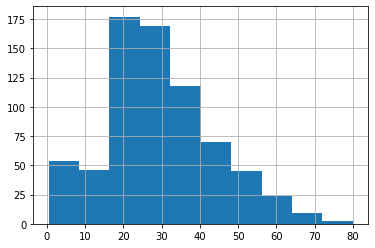

In [26]:
data.Age.hist()

In [27]:
ext = data.Age.mean()+3*data.Age.std() # taking the far end of the distribution.

In [39]:
ext

73.27860964406094

<AxesSubplot:ylabel='Age'>

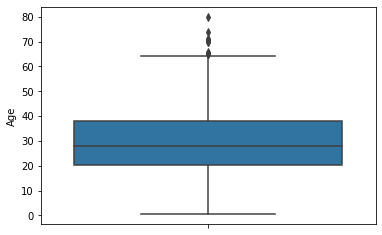

In [28]:
sns.boxplot(y = data.Age)

In [29]:
def impute(data, variable, median, extreme ):
    data[variable+'_end_distribution'] = data[variable].fillna(extreme) # this is the function.
    data[variable].fillna(medain, inplace = True)
    

In [30]:
impute(data, 'Age', data.Age.median(), ext )

In [31]:
data.head()

,Survived,Age,Fare,Age_end_distribution
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


<AxesSubplot:>

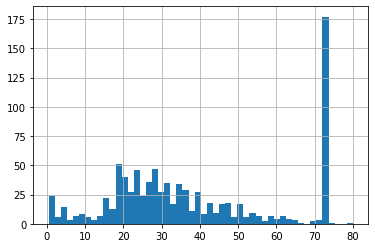

In [32]:
data.Age_end_distribution.hist(bins = 50)
# I am getting the huge value at the end. in case for median we will get at center.

C:\Users\aravi\anaconda3\envs\tensflow\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='Age_end_distribution'>

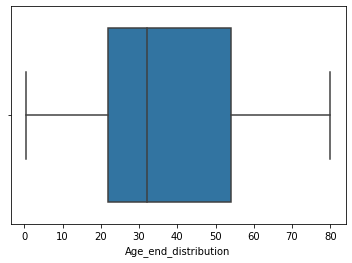

In [33]:
sns.boxplot('Age_end_distribution', data = data)

In [34]:
# it overcome the outliers. nice na!

### 5. Arbitrary Value Imputation
• It replacing the value by arbitrary values.
* Arbitrary values: 1) it should be more frequent present.


In [35]:
data = pd.read_csv('train_titanic.csv',usecols = ['Age', 'Fare','Survived'])

In [36]:
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
def impute_nan(data, variable, arbitrary):
    data[variable+'_arbitrary'] = data[variable].fillna(arbitrary)

In [38]:
impute_nan(data, 'Age', 100)